
studentInfo
----------------------------------------
Shape: (32593, 12)
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   


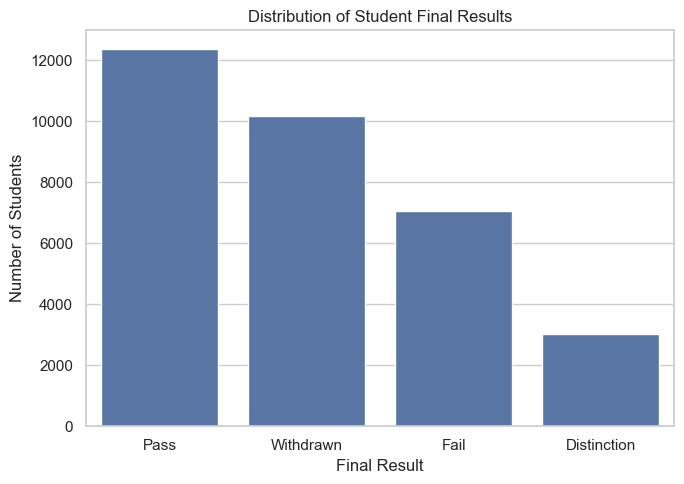


Age Band Counts
age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

Age Band Percentages
age_band
0-35     70.395484
35-55    28.941797
55<=      0.662719
Name: proportion, dtype: float64


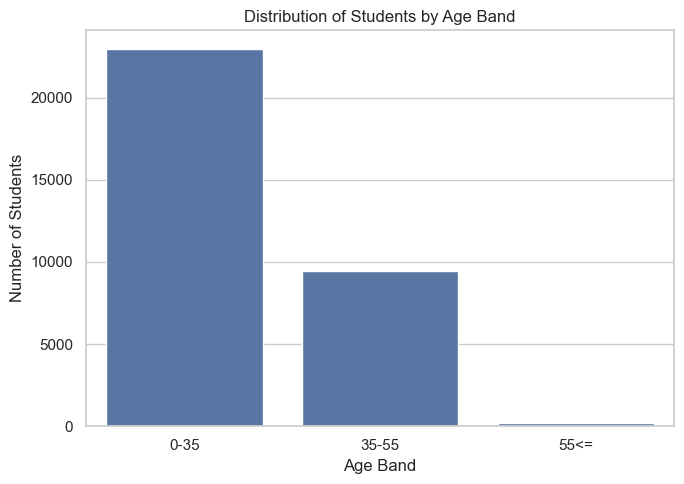


Gender Counts
gender
M    17875
F    14718
Name: count, dtype: int64


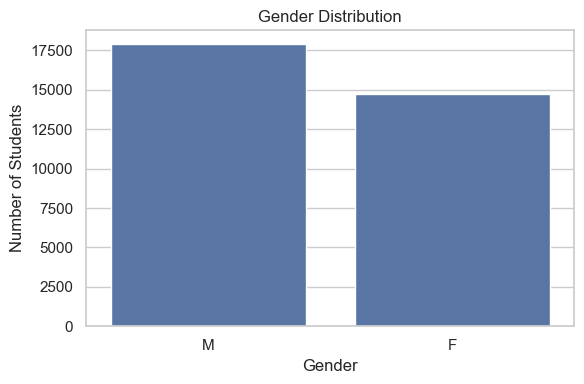


Highest Education Counts
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64


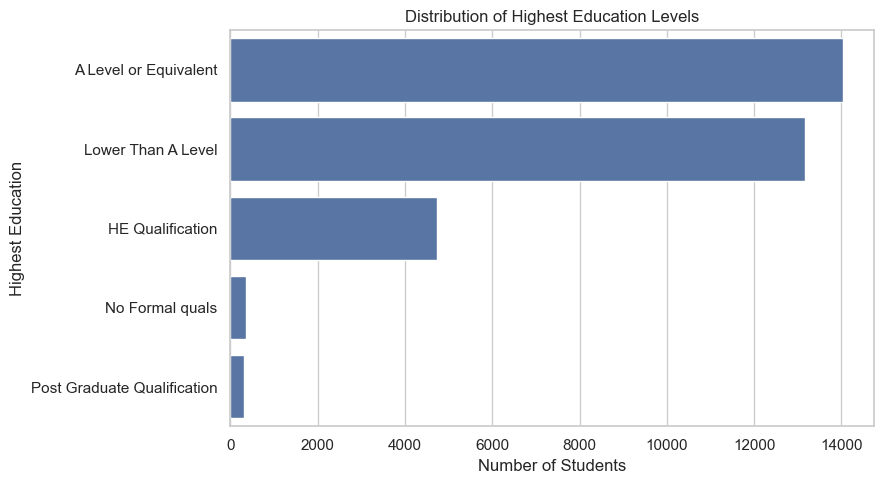


Studied Credits Summary
count    32593.000000
mean        79.758691
std         41.071900
min         30.000000
25%         60.000000
50%         60.000000
75%        120.000000
max        655.000000
Name: studied_credits, dtype: float64


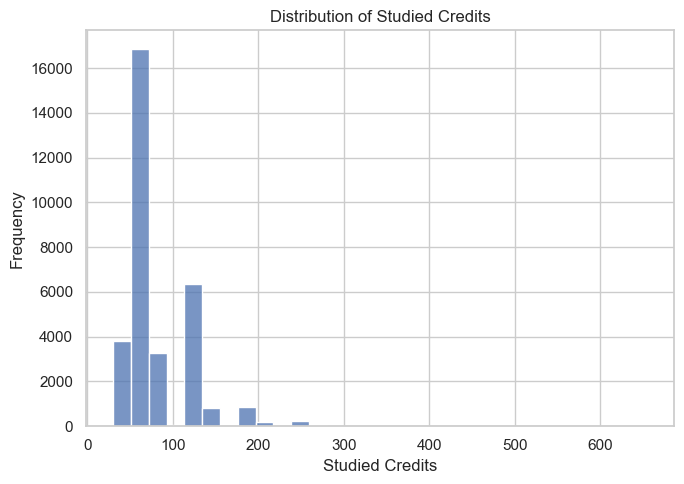


Previous Attempts Summary
count    32593.000000
mean         0.163225
std          0.479758
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
Name: num_of_prev_attempts, dtype: float64


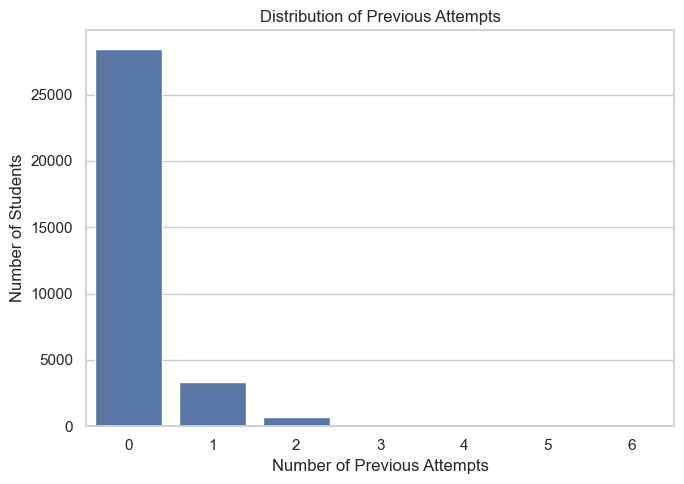


Assessment Score Summary
count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64


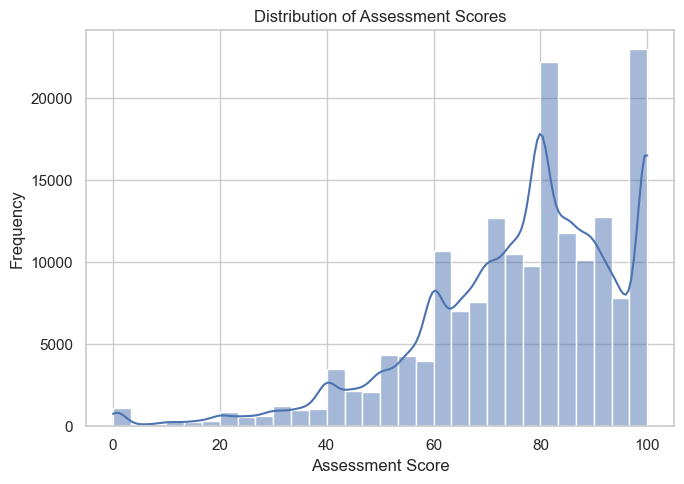


Student Engagement Summary
count    26074.000000
mean      1518.949873
std       1935.994635
min          1.000000
25%        298.000000
50%        824.000000
75%       2018.000000
max      28615.000000
Name: sum_click, dtype: float64


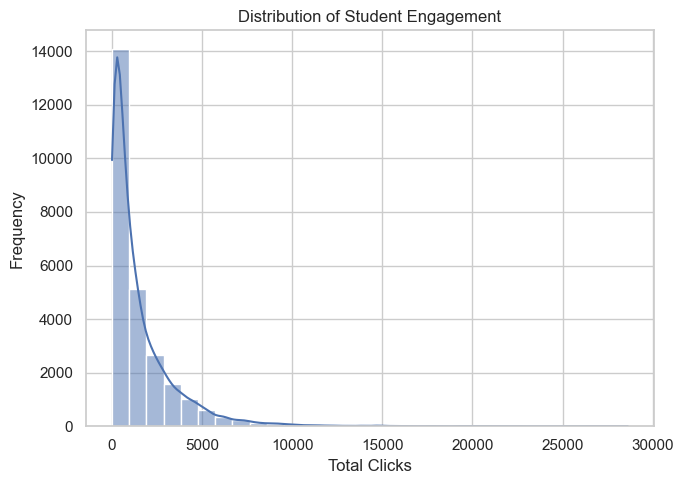


Average Engagement by Final Result
final_result
Distinction    3106.433201
Fail            794.416194
Pass           2170.583448
Withdrawn       628.148582
Name: sum_click, dtype: float64

Median Engagement by Final Result
final_result
Distinction    2218.0
Fail            387.0
Pass           1503.0
Withdrawn       178.0
Name: sum_click, dtype: float64


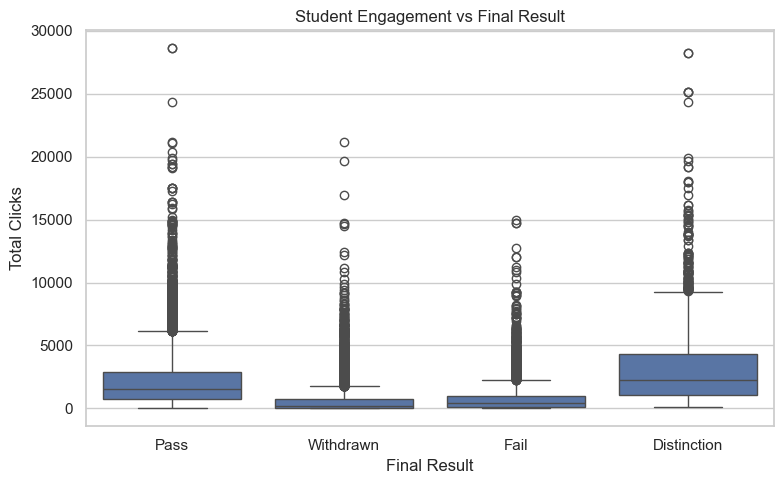


Average Assessment Score by Final Result
final_result
Distinction    88.396467
Fail           64.953882
Pass           76.406586
Withdrawn      68.867723
Name: score, dtype: float64


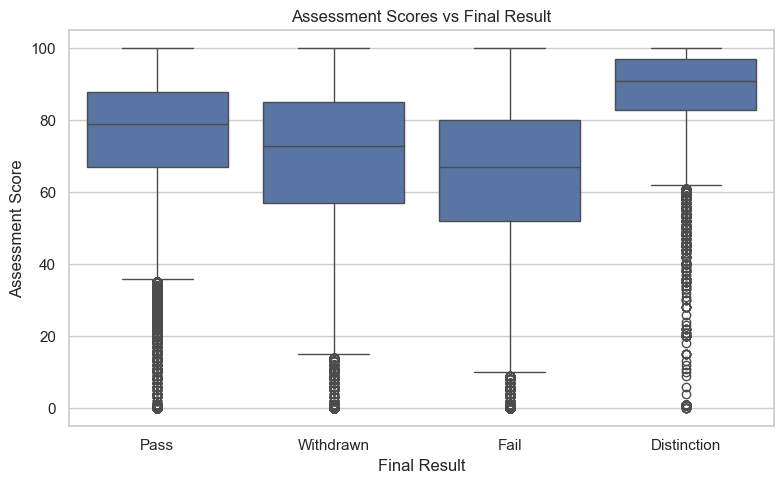

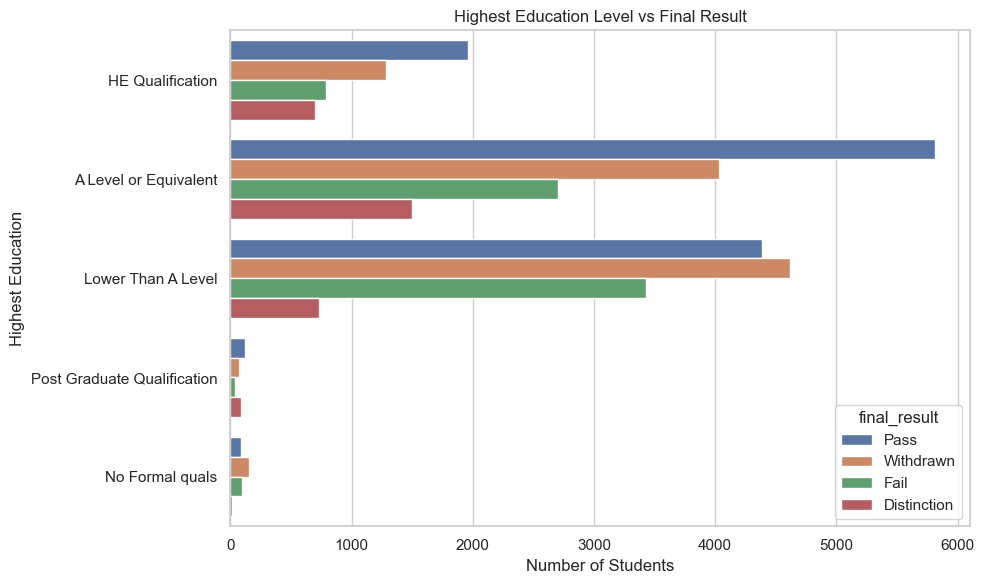

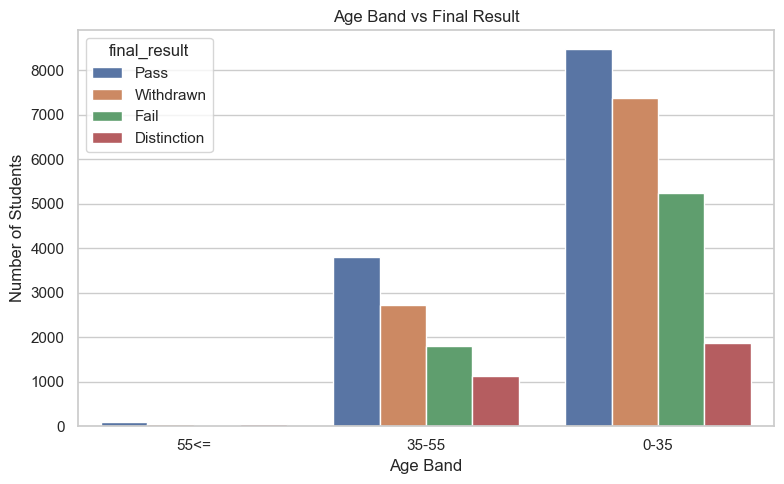


EDA complete. All graphs have been saved as PNG files.


In [3]:
# =========================
# DATA EXPLORATION CODE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------
# 1. Load datasets
# -------------------------

student_info = pd.read_csv("studentInfo.csv")
student_assessment = pd.read_csv("studentAssessment.csv")
assessments = pd.read_csv("assessments.csv")
student_vle = pd.read_csv("studentVle_small.csv")
courses = pd.read_csv("courses.csv")
student_registration = pd.read_csv("studentRegistration.csv")
vle = pd.read_csv("vle.csv")

# -------------------------
# 2. Dataset overview
# -------------------------

datasets = {
    "studentInfo": student_info,
    "studentAssessment": student_assessment,
    "assessments": assessments,
    "studentVle_small": student_vle,
    "courses": courses,
    "studentRegistration": student_registration,
    "vle": vle
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 40)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head())
    print(df.isnull().sum())

# -------------------------
# 3. Missing values
# -------------------------

print("\nMissing Values in studentInfo")
print(student_info.isnull().sum())

print("\nMissing Values in studentAssessment")
print(student_assessment.isnull().sum())

print("\nMissing Values in studentVle_small")
print(student_vle.isnull().sum())

# -------------------------
# 4. Descriptive statistics
# -------------------------

print("\nDescriptive Statistics: studentInfo")
print(student_info.describe())

print("\nDescriptive Statistics: studentAssessment")
print(student_assessment.describe())

print("\nDescriptive Statistics: studentVle_small")
print(student_vle.describe())

# -------------------------
# 5. Target variable counts
# -------------------------

print("\nFinal Result Counts")
print(student_info["final_result"].value_counts())

print("\nFinal Result Percentages")
print(student_info["final_result"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(
    x="final_result",
    data=student_info,
    order=student_info["final_result"].value_counts().index
)
plt.title("Distribution of Student Final Results")
plt.xlabel("Final Result")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("final_result_distribution.png", dpi=300)
plt.show()

# -------------------------
# 6. Age distribution
# -------------------------

print("\nAge Band Counts")
print(student_info["age_band"].value_counts())

print("\nAge Band Percentages")
print(student_info["age_band"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(
    x="age_band",
    data=student_info,
    order=student_info["age_band"].value_counts().index
)
plt.title("Distribution of Students by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("age_distribution.png", dpi=300)
plt.show()

# -------------------------
# 7. Gender distribution
# -------------------------

print("\nGender Counts")
print(student_info["gender"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="gender", data=student_info)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("gender_distribution.png", dpi=300)
plt.show()

# -------------------------
# 8. Highest education distribution
# -------------------------

print("\nHighest Education Counts")
print(student_info["highest_education"].value_counts())

plt.figure(figsize=(9, 5))
sns.countplot(
    y="highest_education",
    data=student_info,
    order=student_info["highest_education"].value_counts().index
)
plt.title("Distribution of Highest Education Levels")
plt.xlabel("Number of Students")
plt.ylabel("Highest Education")
plt.tight_layout()
plt.savefig("highest_education_distribution.png", dpi=300)
plt.show()

# -------------------------
# 9. Studied credits
# -------------------------

print("\nStudied Credits Summary")
print(student_info["studied_credits"].describe())

plt.figure(figsize=(7, 5))
sns.histplot(student_info["studied_credits"], bins=30)
plt.title("Distribution of Studied Credits")
plt.xlabel("Studied Credits")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("studied_credits_distribution.png", dpi=300)
plt.show()

# -------------------------
# 10. Previous attempts
# -------------------------

print("\nPrevious Attempts Summary")
print(student_info["num_of_prev_attempts"].describe())

plt.figure(figsize=(7, 5))
sns.countplot(x="num_of_prev_attempts", data=student_info)
plt.title("Distribution of Previous Attempts")
plt.xlabel("Number of Previous Attempts")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("previous_attempts_distribution.png", dpi=300)
plt.show()

# -------------------------
# 11. Assessment score distribution
# -------------------------

print("\nAssessment Score Summary")
print(student_assessment["score"].describe())

plt.figure(figsize=(7, 5))
sns.histplot(student_assessment["score"].dropna(), bins=30, kde=True)
plt.title("Distribution of Assessment Scores")
plt.xlabel("Assessment Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=300)
plt.show()

# -------------------------
# 12. Student engagement distribution
# -------------------------

print("\nStudent Engagement Summary")
print(student_vle["sum_click"].describe())

plt.figure(figsize=(7, 5))
sns.histplot(student_vle["sum_click"].dropna(), bins=30, kde=True)
plt.title("Distribution of Student Engagement")
plt.xlabel("Total Clicks")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("engagement_distribution.png", dpi=300)
plt.show()

# -------------------------
# 13. Engagement vs final result
# -------------------------

merged = student_info.merge(student_vle, on="id_student", how="left")
merged["sum_click"] = merged["sum_click"].fillna(0)

print("\nAverage Engagement by Final Result")
print(merged.groupby("final_result")["sum_click"].mean())

print("\nMedian Engagement by Final Result")
print(merged.groupby("final_result")["sum_click"].median())

plt.figure(figsize=(8, 5))
sns.boxplot(x="final_result", y="sum_click", data=merged)
plt.title("Student Engagement vs Final Result")
plt.xlabel("Final Result")
plt.ylabel("Total Clicks")
plt.tight_layout()
plt.savefig("engagement_vs_result.png", dpi=300)
plt.show()

# -------------------------
# 14. Assessment scores vs final result
# -------------------------

assessment_merged = student_assessment.merge(
    student_info[["id_student", "final_result"]],
    on="id_student",
    how="left"
)

print("\nAverage Assessment Score by Final Result")
print(assessment_merged.groupby("final_result")["score"].mean())

plt.figure(figsize=(8, 5))
sns.boxplot(x="final_result", y="score", data=assessment_merged)
plt.title("Assessment Scores vs Final Result")
plt.xlabel("Final Result")
plt.ylabel("Assessment Score")
plt.tight_layout()
plt.savefig("assessment_score_vs_result.png", dpi=300)
plt.show()

# -------------------------
# 15. Education level vs final result
# -------------------------

plt.figure(figsize=(10, 6))
sns.countplot(
    y="highest_education",
    hue="final_result",
    data=student_info
)
plt.title("Highest Education Level vs Final Result")
plt.xlabel("Number of Students")
plt.ylabel("Highest Education")
plt.tight_layout()
plt.savefig("education_vs_result.png", dpi=300)
plt.show()

# -------------------------
# 16. Age band vs final result
# -------------------------

plt.figure(figsize=(8, 5))
sns.countplot(
    x="age_band",
    hue="final_result",
    data=student_info
)
plt.title("Age Band vs Final Result")
plt.xlabel("Age Band")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("age_vs_result.png", dpi=300)
plt.show()

print("\nEDA complete. All graphs have been saved as PNG files.")